In [414]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initialise ANN
import NeuralNet
import layer
import dataset
import main

data = dataset.load()
data.head()

,Diagnosis,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [415]:
X_train, Y_train, X_test, Y_test = dataset.train_test(data)

In [416]:
"""REMOVE BEFORE SUBMISSION"""
import importlib
importlib.reload(NeuralNet)
importlib.reload(layer)


ann = NeuralNet.ANN(X_train,Y_train)
activations = [2, 2] # 1-tanh, 2-relu, 3-sigmoid - activations of each layer
ann.setLayers(activations, [2, 2]) # variable arguments represent the number of nodes in each non-input layer 

ann.train_sgd()

# ann_binary = NeuralNet.ANN(0.1,2,X_train,Y_train, 1)
# activations = [2,2] # 1-tanh, 2-relu, 3-sigmoid - activations of each layer
# ann_binary.setLayers(activations, 10, 1) # variable arguments represent the number of nodes in each non-input

(0.5096348613648901, 0.9669603524229075, 0.020908594131469727)

In [417]:
ann.test(X_test, Y_test)

1.0

In [418]:
epochs = [1, 50, 100, 150, 200]

def epoch_test(epochs, int):
    loss = []
    accuracy = []
    time = []

    for i in epochs:
        ann = NeuralNet.ANN(X_train, Y_train, epoch = i, loss = int)
        activations = [3, 3] # 1-tanh, 2-relu, 3-sigmoid - activations of each layer
        ann.setLayers(activations, [2, 2]) # variable arguments represent the number of nodes in each non-input layer 
        l, a, t = ann.train_sgd()
        loss.append(l)
        accuracy.append(a)
        time.append(t)
    return loss, accuracy, time

In [419]:
# hinge
hingeloss, haccuracy, htime = epoch_test(epochs, 2)
print("hinge loss", hingeloss)
print("hinge accuracy", haccuracy)
print("hinge time", htime)

hinge loss [0.06607929515418502, 0.02502202643171803, 0.04621145374449337, 0.03950073421439038, 0.03178414096916302]
hinge accuracy [0.9669603524229075, 0.9889867841409692, 0.9823788546255506, 0.9845814977973568, 0.9977973568281938]
hinge time [0.022009611129760742, 1.0765557289123535, 1.80450439453125, 2.403928756713867, 3.211073398590088]


In [428]:
# binary 
bce, baccuracy, btime = epoch_test(epochs, 1)
print("bce loss", bce)
print("bce accuracy", baccuracy)
print("bce time", btime)

bce loss [0.4077078890917961, 0.19977686565452213, 0.18448781981366216, 0.14768085760410818, 0.20674187542726016]
bce accuracy [0.973568281938326, 0.9889867841409692, 0.9911894273127754, 0.9955947136563876, 0.9911894273127754]
bce time [0.03499937057495117, 0.868999719619751, 1.5280547142028809, 2.3880279064178467, 3.126997947692871]


In [421]:
# square loss
sl, saccuracy, stime = epoch_test(epochs, 3)
print("square loss", sl)
print("square loss accuracy", saccuracy)
print("square loss time", stime)

square loss [0.381057268722467, 0.378502202643172, 0.37863436123348054, 0.3780323054331861, 0.376651982378855]
square loss accuracy [0.973568281938326, 0.9911894273127754, 0.9933920704845814, 0.9823788546255506, 0.9911894273127754]
square loss time [0.035723209381103516, 1.03910493850708, 1.5590028762817383, 2.355992555618286, 3.189013957977295]


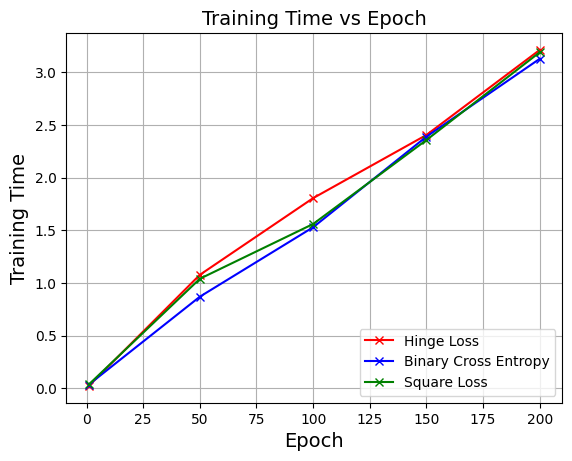

In [461]:
plt.plot(epochs, htime, color = "Red", label = "Hinge Loss", marker = "x")
plt.plot(epochs, btime, color = "Blue", label = "Binary Cross Entropy", marker = "x")
plt.plot(epochs, stime, color = "Green", label = "Square Loss", marker = "x")
plt.title('Training Time vs Epoch', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

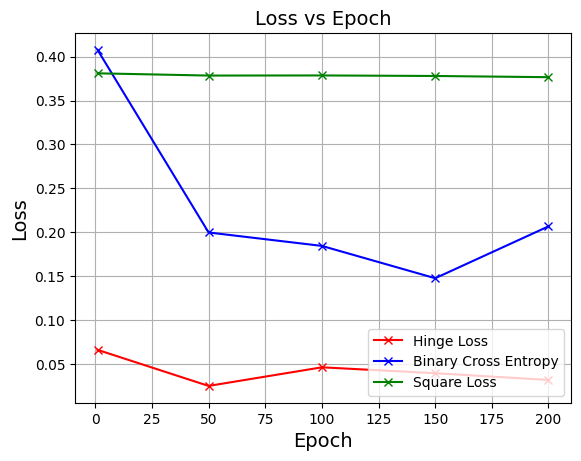

In [462]:
plt.plot(epochs, hingeloss, color = "Red", label = "Hinge Loss", marker = "x")
plt.plot(epochs, bce, color = "Blue", label = "Binary Cross Entropy", marker = "x")
plt.plot(epochs, sl, color = "Green", label = "Square Loss", marker = "x")
plt.title('Loss vs Epoch', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Loss', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

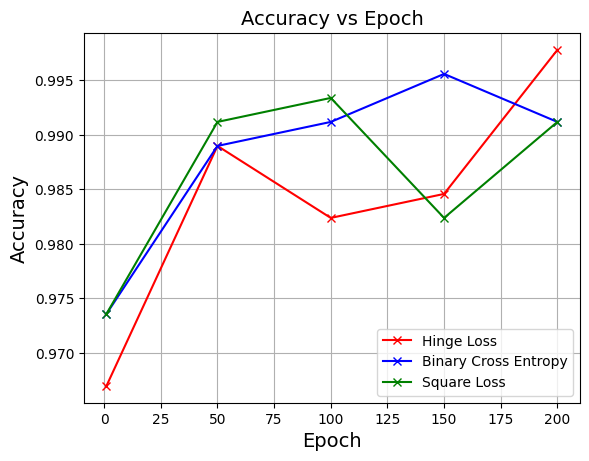

In [463]:
plt.plot(epochs, haccuracy, color = "Red", label = "Hinge Loss", marker = "x")
plt.plot(epochs, baccuracy, color = "Blue", label = "Binary Cross Entropy", marker = "x")
plt.plot(epochs, saccuracy, color = "Green", label = "Square Loss", marker = "x")
plt.title('Accuracy vs Epoch', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

In [440]:
def activation_test(act):
    loss = []
    accuracy = []
    time = []
    ann = NeuralNet.ANN(X_train, Y_train)
    activations = [act, act] # 1-tanh, 2-relu, 3-sigmoid - activations of each layer
    ann.setLayers(activations, [2, 2]) # variable arguments represent the number of nodes in each non-input layer 
    l, a, t = ann.train_sgd()

    return l, a, t

In [452]:
tloss, tacc, ttime = activation_test(1)
print("tan loss", tloss)
print("tan accuracy", tacc)
print("tan time", ttime)

rloss, racc, rtime = activation_test(2)
print("relu loss", rloss)
print("relu accuracy", racc)
print("relu time", rtime)

sloss, sacc, st = activation_test(3)
print("sigmoid loss", sloss)
print("sigmoid accuracy", sacc)
print("sigmoid time", st)

tan loss 1.698782871200842
tan accuracy 0.8898678414096917
tan time 0.018079280853271484
relu loss 0.5775861762136195
relu accuracy 0.9625550660792952
relu time 0.017621278762817383
sigmoid loss 1.46095326924768
sigmoid accuracy 0.9052863436123348
sigmoid time 0.016071081161499023


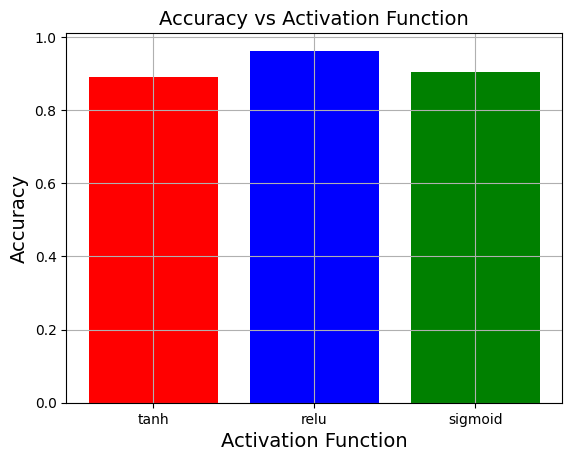

In [466]:
plt.bar(["tanh", "relu", "sigmoid"], [tacc, racc, sacc], color = ["red", "blue", "green"])
plt.title('Accuracy vs Activation Function', fontsize = 14)
plt.xlabel('Activation Function', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.grid(True)
plt.show()

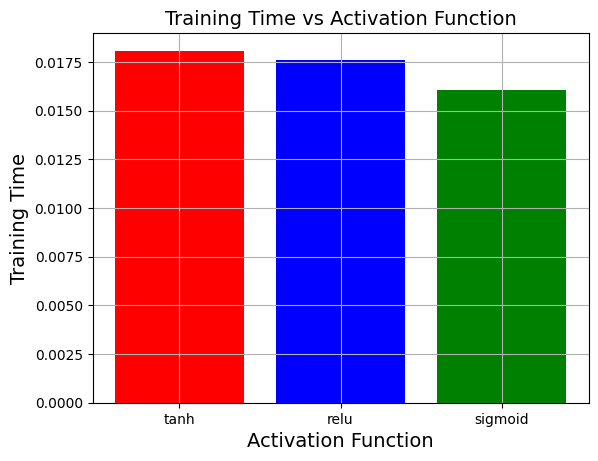

In [465]:
plt.bar(["tanh", "relu", "sigmoid"], [ttime, rtime, st], color = ["red", "blue", "green"])
plt.title('Training Time vs Activation Function', fontsize = 14)
plt.xlabel('Activation Function', fontsize = 14)
plt.ylabel('Training Time', fontsize = 14)
plt.grid(True)
plt.show()

In [495]:
lr = [0.01, 0.05, 0.1, 0.5, 1.0]

def lr_test(lr, sch):
    loss = []
    accuracy = []
    time = []

    for i in lr:
        ann = NeuralNet.ANN(X_train, Y_train, learn_rate = i, lrschedule = sch)
        activations = [2, 2] # 1-tanh, 2-relu, 3-sigmoid - activations of each layer
        ann.setLayers(activations, [2, 2]) # variable arguments represent the number of nodes in each non-input layer 
        l, a, t = ann.train_sgd()
        loss.append(l)
        accuracy.append(a)
        time.append(t)
    return loss, accuracy, time

schloss, schacc, scht = lr_test(lr, 1)
print("learing schedule loss", schloss)
print("learing schedule accuracy", schacc)
print("learing schedule time", scht)
nschloss, nschacc, nscht = lr_test(lr, 0)
print("constant learing loss", nschloss)
print("constant learing accuracy", nschacc)
print("constant learing time", nscht)

learing schedule loss [1.1211966949953382, 1.223123667259737, 0.6455374910623487, 0.3397565742430668, 0.2378296019693932]
learing schedule accuracy [0.9273127753303965, 0.920704845814978, 0.9581497797356828, 0.9779735682819384, 0.9845814977973568]
learing schedule time [0.018999338150024414, 0.015082120895385742, 0.014919757843017578, 0.015000104904174805, 0.01808333396911621]
constant learing loss [1.494928926666248, 1.4609532692302893, 0.5096348613631511, 0.3397565742401685, 0.4077078890917961]
constant learing accuracy [0.9030837004405287, 0.9052863436123348, 0.9669603524229075, 0.9779735682819384, 0.973568281938326]
constant learing time [0.017030954360961914, 0.01488637924194336, 0.015103340148925781, 0.014922142028808594, 0.012048482894897461]


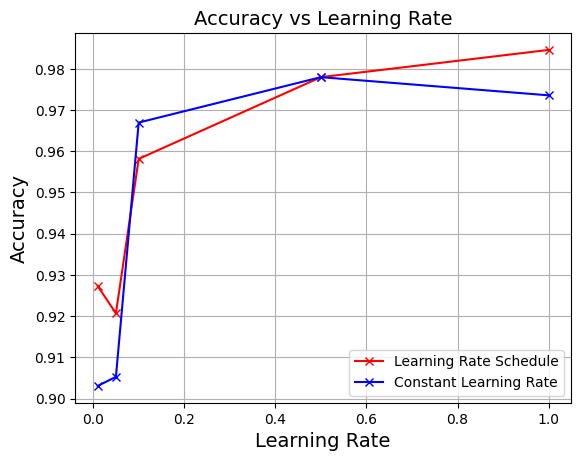

In [496]:
plt.plot(lr, schacc, color = "Red", label = "Learning Rate Schedule", marker = "x")
plt.plot(lr, nschacc, color = "Blue", label = "Constant Learning Rate", marker = "x")
plt.title('Accuracy vs Learning Rate', fontsize = 14)
plt.xlabel('Learning Rate', fontsize = 14)
plt.ylabel('Accuracy', fontsize = 14)
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

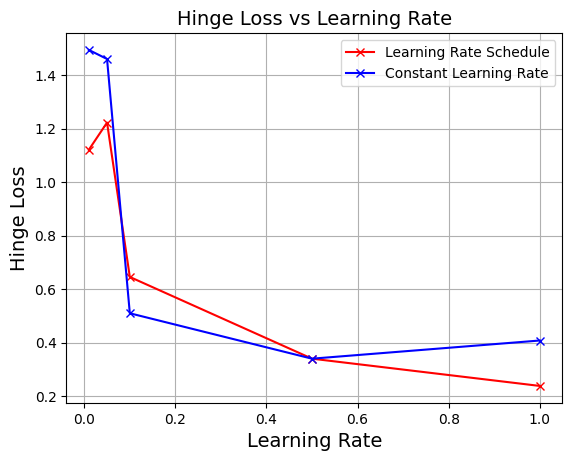

In [498]:
plt.plot(lr, schloss, color = "Red", label = "Learning Rate Schedule", marker = "x")
plt.plot(lr, nschloss, color = "Blue", label = "Constant Learning Rate", marker = "x")
plt.title('Hinge Loss vs Learning Rate', fontsize = 14)
plt.xlabel('Learning Rate', fontsize = 14)
plt.ylabel('Hinge Loss', fontsize = 14)
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()

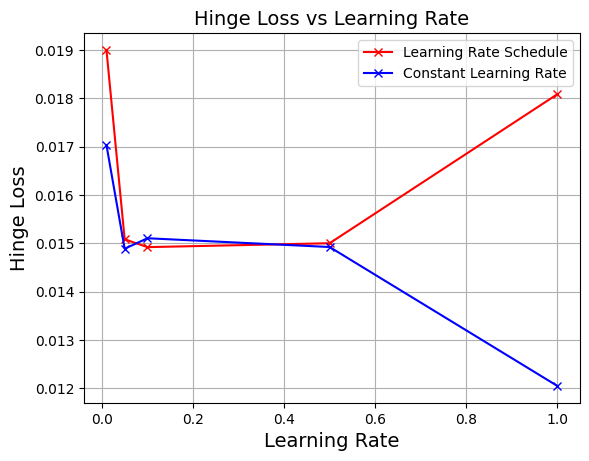

In [499]:
plt.plot(lr, scht, color = "Red", label = "Learning Rate Schedule", marker = "x")
plt.plot(lr, nscht, color = "Blue", label = "Constant Learning Rate", marker = "x")
plt.title('Hinge Loss vs Learning Rate', fontsize = 14)
plt.xlabel('Learning Rate', fontsize = 14)
plt.ylabel('Hinge Loss', fontsize = 14)
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()